In [62]:
import sympy as sp

# Redefine symbolic variables
x, E, b_uc, h_uc, b_s, h_s = sp.symbols('x E b_uc h_uc b_s h_s', real=True, positive=True)
q1, q2, q3, P, q01, q02 = sp.symbols('q1 q2 q3 P q01 q02', real=True)
L = sp.symbols('L', real=True, positive=True)



# Displacement functions
w = q1 * L * sp.sin(sp.pi * x / L) + q2 * L * sp.sin(2 * sp.pi * x / L)
wIMP = q01 * L * sp.sin(sp.pi * x / L) + q02 * L * sp.sin(2 * sp.pi * x / L)
wC = q2 * L * sp.sin(2 * sp.pi * x / L)   #0.5408*
wCIMP = q02 * L * sp.sin(2 * sp.pi * x / L)

# Derivatives
wx = sp.diff(w, x)
wxIMP = sp.diff(wIMP, x)
wxC = sp.diff(wC, x)
wxCIMP = sp.diff(wCIMP, x)
wxx = sp.diff(w, (x, 2))
wxxIMP = sp.diff(wIMP, (x, 2))
wxxC = sp.diff(wC, (x, 2))
wxxCIMP = sp.diff(wCIMP, (x, 2))

# Curvature and integrand expressions
Kxxw = -1 * (wxx + wxx * 1/2 * wx**2 )
KxxwIMP = -1 * (wxxIMP + wxxIMP * 1/2 * wxIMP**2)
KxxwC = -1 * (wxxC + wxxC * 1/2 * wxC**2 )
KxxwCIMP = -1 * (wxxCIMP + wxxCIMP * 1/2 * wxCIMP**2)

intw = (Kxxw - KxxwIMP)**2
intwC = (KxxwC - KxxwCIMP)**2
I = b_uc * h_uc**3 / 12

# Bending energies
Wbend = 1/2 * E * I * sp.integrate(intw, (x, 0, L))
Wbend2 = 1/2 * E * I * sp.integrate(intwC, (x, 0, L))

# Spring stiffness
e = L / 2
ls = (L / 2) * 2**0.5
As = b_s * h_s
k_one = 2 * e**2 / ls**3 * E * As
K_spring = 2 * k_one

# New sigmoid-based spring model parameters
#F0, Fmax, s, a = sp.symbols('F0 Fmax s a', real=True)
#s= 2
#a= 2
# New nonlinear sigmoid spring energy
#x_disp = sp.Abs(q1)* L
#x_disp = q1* L

# Define the force function
#F_sigmoid =5*K_spring / (1 + sp.exp(-s * (x_disp - a)))

a= 0.01 #4.25
b=0.265 
c=40
F_sigmoid = a * sp.exp(c * (x - b)) - a * sp.exp(c * (-x - b))

#F_sigmoid = 0.1 * (sp.exp(alpha * (x) - 1)+sp.exp(alpha * (-x) - 1))
#F_sigmoid = a * sp.exp(c * (x - b)) - a * sp.exp(c * (-x - b))
# Integrate to get energy from x0 to x1
Wspring = sp.integrate(F_sigmoid, (x, 0, q1*L))
Wspring.simplify()

#\Wspring = (Fmax * x_disp * s + sp.log((1 + sp.exp(s * (a - x_disp))) / (1 + sp.exp(s * a))) * (F0 - Fmax)) / s

# Strain energy of the column
A_c = b_uc * h_uc
Wstrain_c = 1/2 * sp.integrate(E * A_c * (q3 / L)**2, (x, 0, L))

# End shortening
wxE = sp.diff(w, x)
wxEimp = sp.diff(wIMP, x)
intSh = 1/2 * wxE**2 + 1/8 * wxE**4
intShimp = 1/2 * wxEimp**2
EndSh = q3 + sp.integrate(intSh, (x, 0, L)) - sp.integrate(intShimp, (x, 0, L))

# Total potential energy
Vin = Wbend + Wbend2 + 2*Wspring + Wstrain_c - P * EndSh
Vin.simplify()


(E*b_uc*h_uc*(0.166666666666667*pi**4*h_uc**2*(pi**4*q02**6 + 2*pi**2*q02**4 - 2*pi**4*q02**3*q2**3 - 2*pi**2*q02**3*q2 + 2*q02**2 - 2*pi**2*q02*q2**3 - 4*q02*q2 + pi**4*q2**6 + 2*pi**2*q2**4 + 2*q2**2) + 0.000651041666666667*pi**4*h_uc**2*(pi**4*q01**6 + 84*pi**4*q01**4*q02**2 + 8*pi**2*q01**4 - 2*pi**4*q01**3*q1**3 - 20*pi**4*q01**3*q1*q2**2 - 8*pi**2*q01**3*q1 + 432*pi**4*q01**2*q02**4 + 320*pi**2*q01**2*q02**2 - 128*pi**4*q01**2*q02*q1**2*q2 - 128*pi**4*q01**2*q02*q2**3 - 256*pi**2*q01**2*q02*q2 + 32*q01**2 - 20*pi**4*q01*q02**2*q1**3 - 608*pi**4*q01*q02**2*q1*q2**2 - 64*pi**2*q01*q02**2*q1 - 8*pi**2*q01*q1**3 - 64*pi**2*q01*q1*q2**2 - 64*q01*q1 + 256*pi**4*q02**6 + 512*pi**2*q02**4 - 128*pi**4*q02**3*q1**2*q2 - 512*pi**4*q02**3*q2**3 - 512*pi**2*q02**3*q2 + 512*q02**2 - 256*pi**2*q02*q1**2*q2 - 512*pi**2*q02*q2**3 - 1024*q02*q2 + pi**4*q1**6 + 84*pi**4*q1**4*q2**2 + 8*pi**2*q1**4 + 432*pi**4*q1**2*q2**4 + 320*pi**2*q1**2*q2**2 + 32*q1**2 + 256*pi**4*q2**6 + 512*pi**2*q2**4 + 512*q

In [63]:
Wspring.simplify()

1.24580048657516e-8*cosh(40*L*q1) - 1.24580048657516e-8

In [64]:
import pyfurc as pf
import sympy as sp
from sympy import solve,latex
#from sympy import *
import numpy as np
import math
from math import pi
import matplotlib.pyplot as plt
from IPython.display import display_latex

In [65]:
Vin_q3=sp.diff(Vin,q3)
print('the first partial derivative with respect to q3',Vin_q3)
q3_passiv = solve(Vin_q3,q3)
print("Solutions for q3:", q3_passiv)
Vin_passiv=Vin.subs(q3,q3_passiv[0])
#print(Vin_passiv)
#Vin.evalf(subs={'q3':q3_passiv}) a certain value

the first partial derivative with respect to q3 1.0*E*b_uc*h_uc*q3/L - P
Solutions for q3: [L*P/(E*b_uc*h_uc)]


In [66]:
def Bifurcation(LIN,EIN,q_01,q_02,b_ucIN,h_ucIN,b_sIN,h_sIN,file_name):
    # define parameters for AUTO-07p
    q1IN=q_01
    q2IN=q_02
    #q3IN=0
    P_start=0
    Pin = pf.Load('P',P_start)
    q1in = pf.Dof('q1',value=q1IN)
    q2in = pf.Dof('q2',value=q2IN)
    #q3in = pf.Dof('q3',value=q3IN)

    q01in = pf.Parameter("q01", value=q1IN, positive=True)      #q01 -- imperfection amplitude for q1
    q02in = pf.Parameter("q02", value=q2IN, positive=True)      #q02 -- imperfection amplitude for q2
    Ein   = pf.Parameter("E",   value=EIN,  positive=True)      #MPa # bending stiffness E*Iyy (with geometry of printed specimens)
    b_sin = pf.Parameter("b_s", value=b_sIN, positive=True)     #b_s the width of the stays
    h_sin = pf.Parameter("h_s", value=h_sIN, positive=True)     #h_s the height of the stays  
    b_ucin= pf.Parameter("b_uc", value=b_ucIN, positive=True)   #b_uc the width of the Unit cell cross-section
    h_ucin= pf.Parameter("h_uc", value=h_ucIN, positive=True)   #h_uc the height of the unit cell cross-section
    #I=bh^3/12
    Lin= pf.Parameter("L", value=LIN, positive=True)            #h the height of the Uc

    V=Vin_passiv.subs([(q1,q1in),(q2,q2in),(P,Pin),
                (q01,q01in),(q02,q02in),(E,Ein),
                (b_s,b_sin),(h_s,h_sin),(b_uc,b_ucin),(h_uc,h_ucin),(L,Lin),(sp.pi,pi)])#3.56#7.13
    V = pf.Energy(V)
    V.info()
 
    V.equilibrium()
    
    bf = pf.BifurcationProblem(V, name="LatticeAK" +str(file_name))
    bf.set_parameter("NPR", 100000)  #label output every NPR
    bf.set_parameter("NMX", 2000000)  #max number of steps #2000000
    bf.set_parameter("DS", 0.00005)  #set step size #0.00005
    bf.set_parameter("DSMAX", 0.0005)
    bf.set_parameter("EPSS", 0.000001)
    #bf.set_parameter("EPSU", 0.001)

    bf.set_parameter("RL0", 0) #min Load  #The lower bound on the principal continuation parameter. Typically this will be the load.
    bf.set_parameter("RL1",40 ) #Max Load

    #Solve Bifurcation Problem
    solver = pf.BifurcationProblemSolver(bf)
    solver.solve()
#ckeck it every time
#q1 - Fortran Name: U(1) - Init. Value: 0.004000
#q2 - Fortran Name: U(2) - Init. Value: 0.004000
    fig,ax1 = plt.subplots()
    plt.xlabel('$q_1$'+str(EIN))
    for dat in bf.solution.raw_data:
        ax1.plot(dat["U(1)"], dat["PAR(1)"])
    
    fig,ax2 = plt.subplots()
    plt.xlabel('$q_2$'+str(EIN))
    for dat in bf.solution.raw_data:
        ax2.plot(dat["U(2)"], dat["PAR(1)"])

Potential energy with 2 DOF(s):
0.5*P**2*L/(E*b_uc*h_uc) - P*(4.56605114221886*q1**4*L + 73.0568182755018*q1**2*q2**2*L + 2.46740110027234*q1**2*L + 73.0568182755018*q2**4*L + 9.86960440108936*q2**2*L + P*L/(E*b_uc*h_uc) - 2.46740110027234*L*q01**2 - 9.86960440108936*L*q02**2) + 0.0416666666666667*E*b_uc*h_uc**3*(37954.1240642823*q2**6/L + 7691.11354860243*q2**4/L - 75908.2481285646*q2**3*q02**3/L - 7691.11354860243*q2**3*q02/L + 779.272728272019*q2**2/L - 7691.11354860243*q2*q02**3/L - 1558.54545654404*q2*q02/L + 37954.1240642823*q02**6/L + 7691.11354860243*q02**4/L + 779.272728272019*q02**2/L) + 0.0416666666666667*E*b_uc*h_uc**3*(148.258297126103*q1**6/L + 12453.6969585926*q1**4*q2**2/L + 120.173649196913*q1**4/L - 296.516594252205*q1**3*q01**3/L - 2965.16594252205*q1**3*q01*q02**2/L - 120.173649196913*q1**3*q01/L + 64047.5843584763*q1**2*q2**4/L + 4806.94596787652*q1**2*q2**2/L - 18977.0620321411*q1**2*q2*q01**2*q02/L - 18977.0620321411*q1**2*q2*q02**3/L - 3845.55677430122*q1**2*q2*

/home/yating/my/myp/lib/python3.12/site-packages/pyfurc/util.py:202: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = read_csv(
/home/yating/my/myp/lib/python3.12/site-packages/pyfurc/util.py:202: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = read_csv(
/home/yating/my/myp/lib/python3.12/site-packages/pyfurc/util.py:202: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = read_csv(
/home/yating/my/myp/lib/python3.12/site-packages/pyfurc/util.py:202: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = read_csv(
/home/yating/my/myp/lib/python3.12/site-packages/pyfurc/util.py:202: FutureWarning: The 

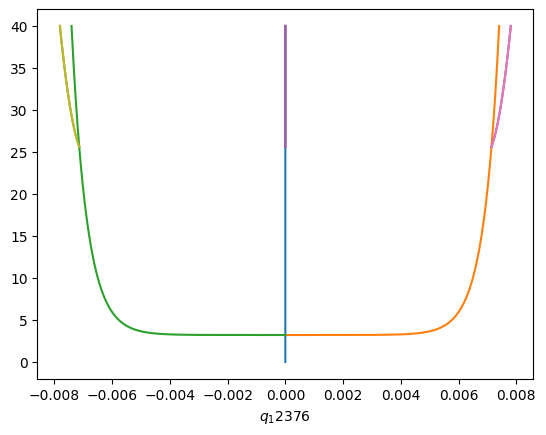

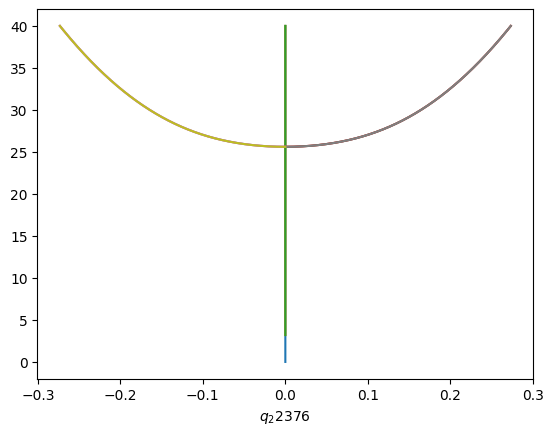

In [67]:
#perfect, 0.2C, 0.4C, 0.2S, 0.2C0.2S, 0.2C0.4S, 0.4C0.2S
q1_IN    =[0]              #q01_value imperfection  [0,0.004,0.008,0.012,0.016]
q2_IN    =[0]
#q1_IN    =[0, 0.004, 0.008, 0,     0.004, 0.004, 0.008]                #q01_value imperfection  [0,0.004,0.008,0.012,0.016]
#q2_IN    =[0, 0,     0,     0.004, 0.004, 0.008, 0.004]              #q02_value imperfection
#q1_IN    =[0, 0.004, 0.008, 0]                
#q2_IN    =[0, 0,     0,     0.004]
E_IN     =2376   # 1896
b_s_IN   =0.4           #b_s the width of the stays
h_s_IN   =0.4           #h_s the height of the stays
b_uc_IN  =8             #b_uc the width of the Unit cell cross-section
h_uc_IN  =0.8           #h_uc the height of the unit cell cross-section
L_IN     =50

FN= np.arange(0,len(q1_IN),1)#file_name
for i in np.arange(0,len(q1_IN),1):
    #Bifurcation(LIN,EIN,q_01,q_02,b_ucIN,h_ucIN,b_sIN,h_sIN,file_name)
    Bifurcation(L_IN,E_IN,q1_IN[i],q2_IN[i],b_uc_IN,h_uc_IN,b_s_IN,h_s_IN,FN[i])

The following section only describes the data processing used for generating the plot. It is not key related to the model

In [71]:
EE=np.arange(0,len(q1_IN),1) #file name
import glob, os
import pandas as pd
EE_len = np.arange(0,len(EE),1) 
index_number= []
for ii in EE_len:
    files = 'a=0.01'  #LatticeAK0_20250526_174420#glob.glob("*" + glob.escape('LatticeAK'+str(EE[ii]))+'_'+"*"
    a=files
    print(str(a)+'/fort.7')
    read_file = pd.read_csv (str(a)+'/fort.7')
    read_file.to_csv ('Total Data'+str(EE[ii])+'.csv', index=None)
    #specify rows to import
    specific_rows = [0,1,2,3,4,5,6,7,8,9,10]#delete the first few extra lines
    #import specific rows from CSV into DataFrame
    #df = pd.read_csv('File name.csv', skiprows = lambda x: x not in specific_rows)
    df = pd.read_csv('Total Data'+str(EE[ii])+'.csv', skiprows = specific_rows)
    df.columns=["Data"]
    #iew DataFrame
    #df.to_csv('Total Data'+str(EE[ii])+'.csv') #
    #print(df)
    
    #df = pd.read_csv ('Total Data'+str(EE[ii])+'.csv')
    #print('Total Data'+str(EE[ii])+'.csv')
    solution_Number = df.loc[df['Data'].str.contains('PT')] # table
    #print(solution_Number)
    index=solution_Number.index.values
    #print(index)
    print('The total number of rows/solutions is:'+str(EE[ii]),len(solution_Number.index))#nummber
    index_number.append(len(solution_Number.index))
    #print(solution_Number)
    
     
    import numpy as np
    if len(solution_Number.index) == 1:
        Solution = df
        Solution_split=Solution["Data"].str.split(expand=True).add_prefix("Data_")
        Solution_split.to_csv('Solution0_'+str(EE[ii])+'.csv')
    else:
        for i in np.arange(0,len(solution_Number.index)-1):
            Solution = df.iloc[index[i]:index[i+1]-1]  # form row1 to row20 #
            Solution.columns=['Data'+str(i)]# defination the name of columns
            Solution_split=Solution['Data'+str(i)].str.split(expand=True).add_prefix('Data'+'_') # '\s' every space will be tanken,falsch
            #ad_prefix('Data'+str(i)+'_')
            #view DataFrame
            Solution_split.to_csv('Solution'+str(i)+'_'+str(EE[ii])+'.csv')
            #print(i)
            
            # last solution
        Solution_last = df.iloc[index[len(solution_Number.index)-1]:]  # form row1 to row20 #
        Solution_last.columns=['Data']# defination the name of columns
        Solution_last_split=Solution_last['Data'].str.split(expand=True).add_prefix('Data'+'_') # '\s' every space will be tanken,falsch
    #ad_prefix('Data'+str(i)+'_')
    #view DataFrame
        Solution_last_split.to_csv('Solution'+str(len(solution_Number.index)-1)+'_'+str(EE[ii])+'.csv')
print(index_number)

a=0.01/fort.7
The total number of rows/solutions is:0 9
[9]


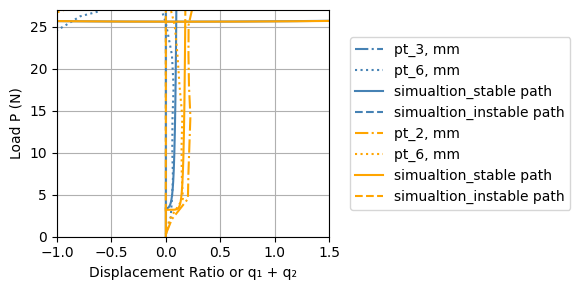

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the processed Excel file
xlsx_path = 'UC_0.8_perfect_shifted_1.xlsx'  #10,13 UC_20250313_UC_Ri_13
#mean_P_vs_ratio_with_time_13_10_1
df_ratio = pd.read_excel(xlsx_path)

# Try loading Solution0,1,5,6 for q1+q2 vs PAR
solution_data = []

for i in [0, 1, 5, 6]:
    try:
        csv_path = f'Solutiona=4/Solution{i}_0.csv'
        df = pd.read_csv(csv_path, skiprows=[1])
        q1 = df['Data_6'] * 50 / 2
        q2 = df['Data_7'] * 50
        q_total = q1 + q2
        PAR = df['Data_4']
        solution_data.append((q_total, PAR, i))
    except FileNotFoundError:
        continue

# Prepare plot
#plt.figure(figsize=(7, 3))
plt.figure(figsize=(6, 3))
styles = ['-.', ':',   ]
markers = ['o', 's']

for idx, i in enumerate([3, 6]):
    subset = df_ratio[df_ratio["Point"] == f"pt_{i}"]
    plt.plot(subset["ratio_shifted"], subset["P"],
             label=f'pt_{i}, mm',
             linestyle=styles[idx],
             #marker=markers[idx],
             color='steelblue',
             #markersize=4
    )

# Plot q1+q2 vs PAR with masks for Solution 0 & 1
# Plot q1+q2 vs PAR with masks for Solution 0 & 1
for q_total, PAR, idx in solution_data:
    #color = "steelbule"   # force all black
    
    if idx == 0:
        thr = 10
        mask_solid = PAR <= thr
        mask_dash  = PAR > thr
        plt.plot(q_total[mask_solid], PAR[mask_solid],
                 linestyle='-', color="steelblue", label="simualtion_stable path")
        plt.plot(q_total[mask_dash], PAR[mask_dash],
                 linestyle='--', color="steelblue", label="simualtion_instable path")
        
    elif idx == 1:
        thr = 86
        mask_solid = PAR <= thr
        mask_dash  = PAR > thr
        plt.plot(q_total[mask_solid], PAR[mask_solid],
                 linestyle='-', color="steelblue") #, label="Solution 1 (≤ 86)"
        plt.plot(q_total[mask_dash], PAR[mask_dash],
                 linestyle='--', color="steelblue") #, label="Solution 1 (> 86)"
        
    else:  # Solutions 5 and 6 (normal)
        plt.plot(q_total, PAR, linestyle='-', color="steelblue") #, label=f"Solution {idx}"




# Load the processed Excel file
xlsx_path = 'b0.8_1.4mean_DIC.xlsx'  #20260203_UC0.8_1.4_DIC_shifted6
#mean_P_vs_ratio_with_time_13_10_1
df_ratio_1 = pd.read_excel(xlsx_path)

# Try loading Solution0,1,5,6 for q1+q2 vs PAR
solution_data = []

for i in [0, 1, 5, 6]:
    try:
        csv_path = f'Solution{i}_0.csv'
        df = pd.read_csv(csv_path, skiprows=[1])
        q1 = df['Data_6'] * 50 / 2
        q2 = df['Data_7'] * 50
        q_total = q1 + q2
        PAR = df['Data_4']
        solution_data.append((q_total, PAR, i))
    except FileNotFoundError:
        continue

# Plot pt_2 and pt_7 from Excel data
styles = ['-.', ':',   ]
markers = ['o', 's']

for idx, i in enumerate([2, 6]):
    subset = df_ratio_1[df_ratio_1["Point"] == f"pt_{i}"]
    plt.plot(subset["ratio_shifted"], subset["P"],
             label=f'pt_{i}, mm',
             linestyle=styles[idx],
             #marker=markers[idx],
             color='orange',
             #markersize=4
    )



# Plot q1+q2 vs PAR with masks for Solution 0 & 1
# Plot q1+q2 vs PAR with masks for Solution 0 & 1
for q_total, PAR, idx in solution_data:
    color = "k"   # force all black
    
    if idx == 0:
        thr = 3
        mask_solid = PAR <= thr
        mask_dash  = PAR > thr
        plt.plot(q_total[mask_solid], PAR[mask_solid],
                 linestyle='-', color='orange', label="simualtion_stable path")
        plt.plot(q_total[mask_dash], PAR[mask_dash],
                 linestyle='--', color='orange', label="simualtion_instable path")
        
    elif idx == 1:
        thr = 25
        mask_solid = PAR <= thr
        mask_dash  = PAR > thr
        plt.plot(q_total[mask_solid], PAR[mask_solid],
                 linestyle='-', color='orange') #, label="Solution 1 (≤ 86)"
        plt.plot(q_total[mask_dash], PAR[mask_dash],
                 linestyle='--', color='orange') #, label="Solution 1 (> 86)"
        
    else:  # Solutions 5 and 6 (normal)
        plt.plot(q_total, PAR, linestyle='-', color='orange') #, label=f"Solution {idx}"


# Labels and layout
plt.xlabel("Displacement Ratio or q₁ + q₂")
plt.ylabel("Load P (N)")
#plt.ylim(0, 15)
#plt.xlim(-0.1, 0.23)
plt.ylim(0, 27)
plt.xlim(-1, 1.5)
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.tight_layout()
plt.show()

/tmp/ipykernel_11531/1408905520.py:114: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


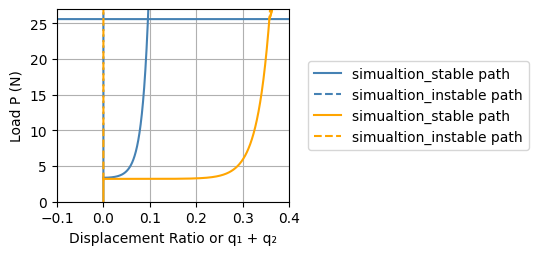

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the processed Excel file
xlsx_path = 'UC_0.8_perfect_shifted_1.xlsx'  #10,13 UC_20250313_UC_Ri_13
#mean_P_vs_ratio_with_time_13_10_1
df_ratio = pd.read_excel(xlsx_path)

# Try loading Solution0,1,5,6 for q1+q2 vs PAR
solution_data = []

for i in [0, 1, 5, 6]:
    try:
        csv_path = f'Solutiona=4/Solution{i}_0.csv'
        df = pd.read_csv(csv_path, skiprows=[1])
        q1 = df['Data_6'] * 50 / 2
        q2 = df['Data_7'] * 50
        q_total = q1 + q2
        PAR = df['Data_4']
        solution_data.append((q_total, PAR, i))
    except FileNotFoundError:
        continue

# Prepare plot
#plt.figure(figsize=(7, 3))
plt.figure(figsize=(3, 2.5))

# Plot q1+q2 vs PAR with masks for Solution 0 & 1
# Plot q1+q2 vs PAR with masks for Solution 0 & 1
for q_total, PAR, idx in solution_data:
    color = 'steelblue'   # force all black
    
    if idx == 0:
        thr = 10
        mask_solid = PAR <= thr
        mask_dash  = PAR > thr
        plt.plot(q_total[mask_solid], PAR[mask_solid],
                 linestyle='-', color=color, label="simualtion_stable path")
        plt.plot(q_total[mask_dash], PAR[mask_dash],
                 linestyle='--', color=color, label="simualtion_instable path")
        
    elif idx == 1:
        thr = 86
        mask_solid = PAR <= thr
        mask_dash  = PAR > thr
        plt.plot(q_total[mask_solid], PAR[mask_solid],
                 linestyle='-', color=color) #, label="Solution 1 (≤ 86)"
        plt.plot(q_total[mask_dash], PAR[mask_dash],
                 linestyle='--', color=color) #, label="Solution 1 (> 86)"
        
    else:  # Solutions 5 and 6 (normal)
        plt.plot(q_total, PAR, linestyle='-', color=color) #, label=f"Solution {idx}"




# Load the processed Excel file
xlsx_path = 'b0.8_1.4mean_DIC.xlsx'  #20260203_UC0.8_1.4_DIC_shifted6
#mean_P_vs_ratio_with_time_13_10_1
df_ratio_1 = pd.read_excel(xlsx_path)

# Try loading Solution0,1,5,6 for q1+q2 vs PAR
solution_data = []

for i in [0, 1, 5,6]:
    try:
        csv_path = f'Solution{i}_0.csv'
        df = pd.read_csv(csv_path, skiprows=[1])
        q1 = df['Data_6'] * 50
        q2 = 0#df['Data_7'] * 50
        q_total = q1 + q2
        PAR = df['Data_4']
        solution_data.append((q_total, PAR, i))
    except FileNotFoundError:
        continue


# Plot q1+q2 vs PAR with masks for Solution 0 & 1
# Plot q1+q2 vs PAR with masks for Solution 0 & 1
for q_total, PAR, idx in solution_data:
    color = "k"   # force all black
    
    if idx == 0:
        thr = 3
        mask_solid = PAR <= thr
        mask_dash  = PAR > thr
        plt.plot(q_total[mask_solid], PAR[mask_solid],
                 linestyle='-', color='orange', label="simualtion_stable path")
        plt.plot(q_total[mask_dash], PAR[mask_dash],
                 linestyle='--', color='orange', label="simualtion_instable path")
        
    elif idx == 1:
        thr = 25
        mask_solid = PAR <= thr
        mask_dash  = PAR > thr
        plt.plot(q_total[mask_solid], PAR[mask_solid],
                 linestyle='-', color='orange') #, label="Solution 1 (≤ 86)"
        plt.plot(q_total[mask_dash], PAR[mask_dash],
                 linestyle='--', color='orange') #, label="Solution 1 (> 86)"
        
    else:  # Solutions 5 and 6 (normal)
        plt.plot(q_total, PAR, linestyle='-', color='orange') #, label=f"Solution {idx}"


# Labels and layout
plt.xlabel("Displacement Ratio or q₁ + q₂")
plt.ylabel("Load P (N)")
plt.ylim(0, 27)
plt.xlim(-0.1, 0.4)
#plt.ylim(0, 27)
#plt.xlim(-1, 1.5)
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.tight_layout()
plt.show()

In [69]:
    I_value=1.152
    E_module=2376 #1896

    #q1_IN    =[0, 0.004, 0.008, 0,     0.004, 0.004, 0.008]                
    #q2_IN    =[0, 0,     0,     0.004, 0.004, 0.008, 0.004] 
    #q1_IN    =[0, 0.004, 0.008, 0]                
    #q2_IN    =[0, 0,     0,     0.004]
    q1_IN    =[0]   #0.2C 0.4C 0.8C              
    q2_IN    =[0]
    #q_02 = [ x/0.9 for x in q_02_initial]
    EE=np.arange(0,len(q1_IN),1) #file_name
    EE_len = np.arange(0,len(EE),1) 
    #EE_len=[0]
    print(index_number)
    for ii in EE_len:
        XXX=np.arange(0,index_number[ii],1)
        for i in XXX:
            p1 = pd.read_csv('Solution'+str(i)+'_'+str(EE[ii])+'.csv',skiprows=[1], usecols = ['Data_4'])
            q21 = pd.read_csv('Solution'+str(i)+'_'+str(EE[ii])+'.csv',skiprows=[1], usecols = ['Data_6']) #u1
            q11 = pd.read_csv('Solution'+str(i)+'_'+str(EE[ii])+'.csv',skiprows=[1], usecols = ['Data_7']) #u2
            #q11 = pd.read_csv('Solution'+str(i)+'_'+str(EE[ii])+'.csv',skiprows=[1], usecols = ['Data_8']) #u3
            
            names = locals()
            names['P_' + str(i)+ '_'+str(EE[ii])]=[]
            names['Q1_' + str(i)+ '_'+str(EE[ii])]=[]
            names['Q2_' + str(i)+ '_'+str(EE[ii])]=[]
            #names['Q3_' + str(i)+ '_'+str(EE[ii])]=[]
            
            names['Delta_' + str(i)+ '_'+str(EE[ii])]=[]
            names['P_Sh_' + str(i)+ '_'+str(EE[ii])]=[]
            names['Q2_Sh_' + str(i)+ '_'+str(EE[ii])]=[]
            names['Q_Total_' + str(i)+ '_'+str(EE[ii])] = []
            
            names['P_' + str(i)+ '_'+str(EE[ii])]= np.transpose(np.array(p1,dtype=np.float32))[0]  #/8.61
            names['Q1_' + str(i)+ '_'+str(EE[ii])]= np.transpose(np.array(q11,dtype=np.float32))[0]
            names['Q2_' + str(i)+ '_'+str(EE[ii])]= np.transpose(np.array(q21,dtype=np.float32))[0]
            #names['Q3_' + str(i)+ '_'+str(EE[ii])]= np.transpose(np.array(q31,dtype=np.float32))[0]

            PP_index=np.arange(0,len(names['Q2_' + str(i)+ '_'+str(EE[ii])]),100)
            for iii in PP_index:
                #q3_value = q3_passiv[0].evalf(subs={'E':E_module,'b_uc':b_uc_IN,'h_uc':h_uc_IN,L:L_IN,'P':names['P_' + str(i)+ '_'+str(EE[ii])][iii]})
            #delta=q3+Endsh of bending---------------------------------------------------------------------------------------------------------------------------------------------------------------
                #deformation=EndSh.evalf(subs={'q1':names['Q1_' + str(i)+ '_'+str(EE[ii])][iii],'q2':names['Q2_' + str(i)+ '_'+str(EE[ii])][iii],q3:q3_value,q01:q1_IN[ii],q02:q2_IN[ii],L:50})
            #----------------------------------------------------------------------------------------------------------------------------------------------------------------
                #names['Delta_' + str(i)+ '_'+str(EE[ii])].append(deformation)
                
                p123=names['P_' + str(i)+ '_'+str(EE[ii])][iii]
                names['P_Sh_' + str(i)+ '_'+str(EE[ii])].append(p123)
                
                q2_123=names['Q2_' + str(i)+ '_'+str(EE[ii])][iii]
                names['Q2_Sh_' + str(i)+ '_'+str(EE[ii])].append(q2_123)
                
                q_total_123 = names['Q1_' + str(i)+ '_'+str(EE[ii])][iii] + names['Q2_' + str(i)+ '_'+str(EE[ii])][iii]
                names['Q_Total_' + str(i)+ '_'+str(EE[ii])].append(q_total_123)
            
            # Create a DataFrame from the arrays
            df = pd.DataFrame({
                #'Delta': names['Delta_' + str(i)+ '_'+str(EE[ii])],
                'P_Sh': names['P_Sh_' + str(i)+ '_'+str(EE[ii])],
                'Q2_Sh': names['Q2_Sh_' + str(i)+ '_'+str(EE[ii])],
                'Q_Total': names['Q_Total_' + str(i)+ '_'+str(EE[ii])]
            })
            #
           # Save the DataFrame to a CSV file
            df.to_csv('P_Delta'+str(i)+str(ii)+'_.csv', index=False)    

[9]


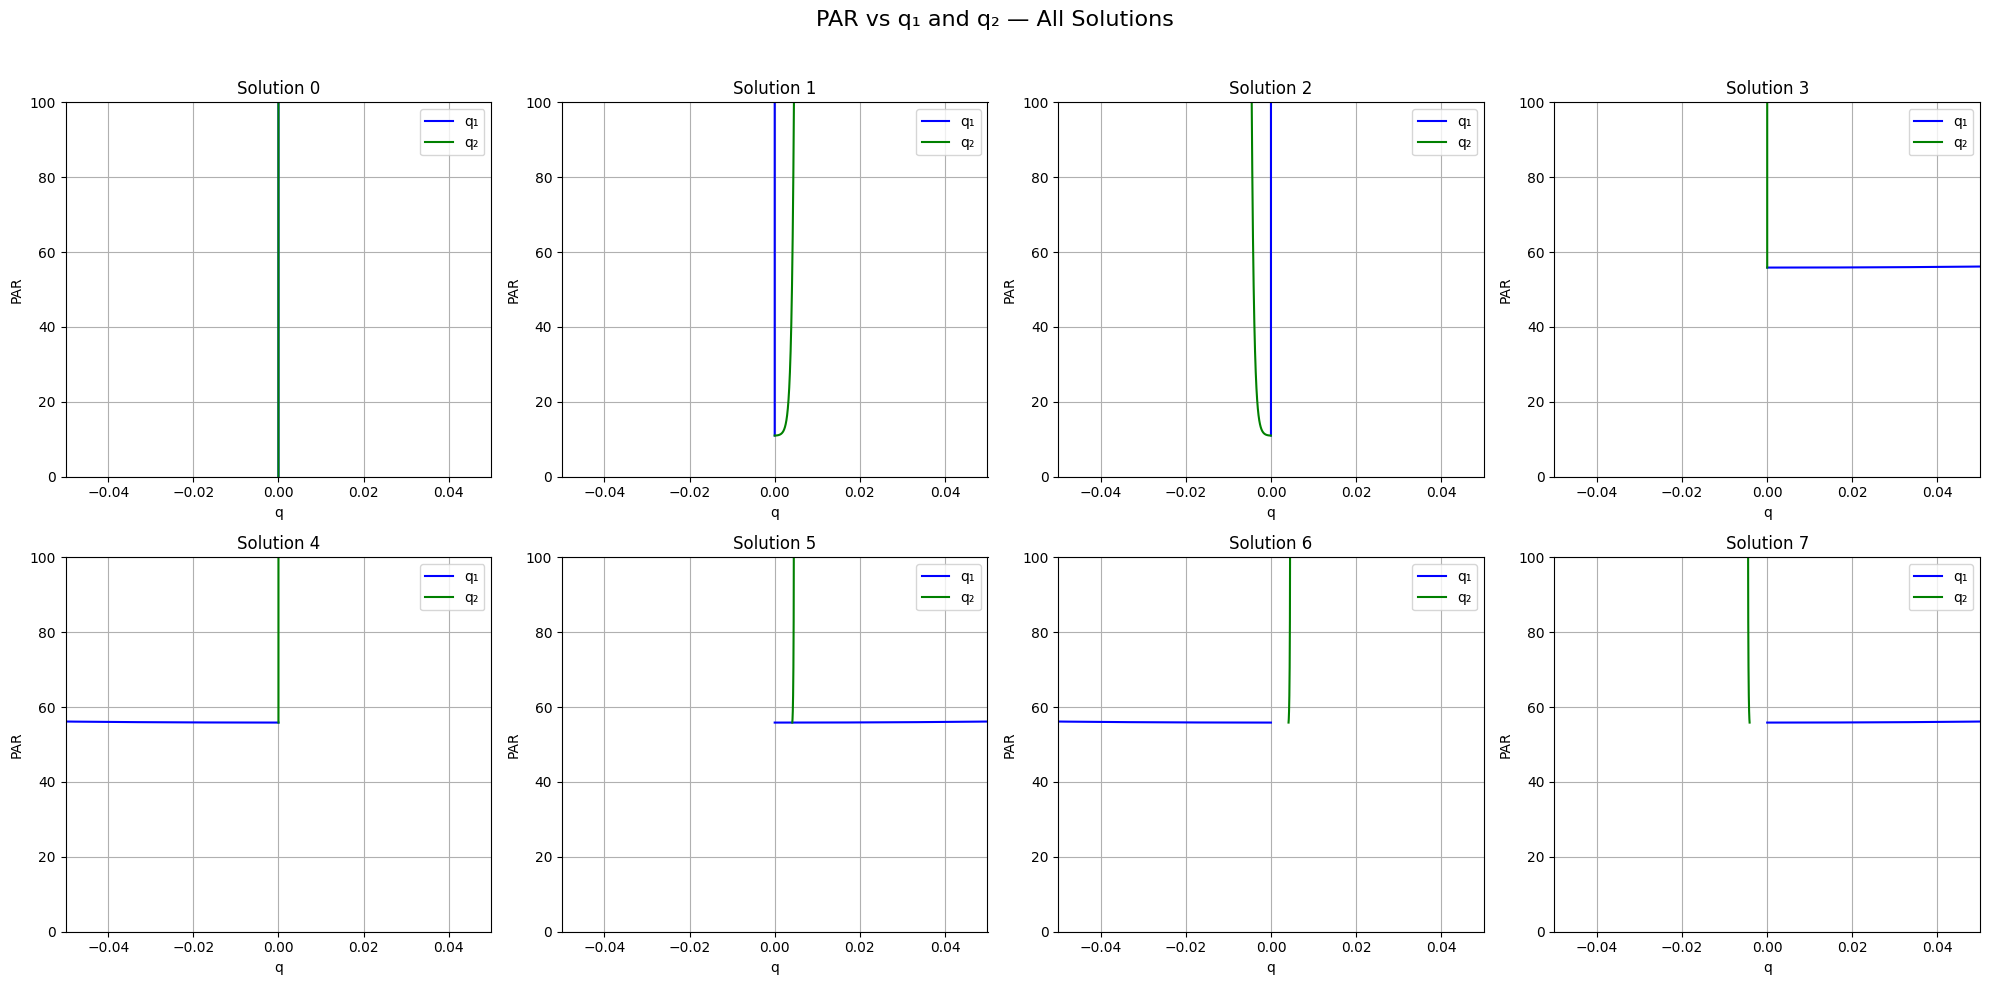

In [143]:
# Create the 2x4 plot layout again with updated axis labels
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Reload and plot each solution with updated labels
for i in range(8):
    ax = axes[i]
    file_path = f'Solution{i}_0.csv'
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, skiprows=[1])
        # q1 = Data_7, q2 = Data_6, PAR = Data_4
        ax.plot(df['Data_7'], df['Data_4'], label='q₁', color='blue')
        if 'Data_8' in df.columns:
            ax.plot(df['Data_8'], df['Data_4'], label='q₂', color='green')
        elif 'Data_6' in df.columns:
            ax.plot(df['Data_6'], df['Data_4'], label='q₂', color='green')
        ax.set_title(f'Solution {i}')
        ax.set_xlabel('q')
        ax.set_ylabel('PAR')
        ax.set_ylim(0, 100)
        ax.set_xlim(-0.05, 0.05)
        ax.grid(True)
        ax.legend()
    else:
        ax.set_visible(False)

plt.suptitle('PAR vs q₁ and q₂ — All Solutions', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [15]:
def axis_at_origin(ax, xlim, ylim, xlabel, ylabel):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # Hide default spines/ticks
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.grid(False)

    # ---- X axis ----
    ax.plot([xlim[0], 0], [0, 0], '-', color='black', lw=1.2)  # solid negative x-axis
    ax.plot([0, xlim[1]], [0, 0], '-', color='black', lw=1.2)  # solid positive x-axis
    ax.annotate('', xy=(xlim[1], 0), xytext=(xlim[1] - 0.02*(xlim[1]-xlim[0]), 0),
                arrowprops=dict(arrowstyle='-|>', lw=1.2, color='black'))

    # ---- Y axis ----
    ax.plot([0, 0], [0, ylim[1]], '-', color='black', lw=1.2)
    ax.annotate('', xy=(0, ylim[1]), xytext=(0, ylim[1] - 0.05*(ylim[1]-ylim[0])),
                arrowprops=dict(arrowstyle='-|>', lw=1.2, color='black'))

    # ---- Custom ticks ----
    xticks = [-2,-1,0,1,2]
    yticks = [0,25, 50, 75,100]

    for tx in xticks:
        if tx == 0:
            ax.annotate("0", xy=(0, 0), xycoords='data',
                        xytext=(-10, -10), textcoords='offset points',
                        ha='center', va='center', fontsize=14)  # origin label
        else:
            ax.annotate(f"{tx:.1f}", xy=(tx, 0), xycoords='data',
                        xytext=(0, -10), textcoords='offset points',
                        ha='center', va='top', fontsize=14)

    for ty in yticks:
        if ty != 0:  # skip origin to avoid double label
            ax.annotate(f"{ty:g}", xy=(0, ty), xycoords='data',
                        xytext=(-8, 0), textcoords='offset points',
                        ha='right', va='center', fontsize=14)

    # ---- Axis labels ----
    ax.text(xlim[1], 0, '  ' + xlabel, va='center', ha='left', fontsize=14)  # x-label
    ax.text(0.05, ylim[1] * 0.95, ylabel, va='bottom', ha='center', fontsize=14, rotation=0)  # y-label near arrow


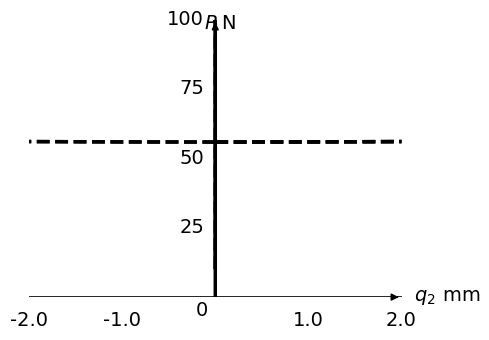

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# ---- settings ----
xlim = (-2, 2)
ylim = (0, 100)          # P (PAR)
par_threshold = 10#220
line_thickness = 2.5     # <--- adjust thickness here

# ---- load & plot ----
fig, ax = plt.subplots(figsize=(5, 3.5))
axis_at_origin(ax, xlim, ylim, r'$q_2$ mm', r'$P$ N')

for i in [0, 1,2,3,4,5,6,7]:
    file_path = f'Solution{i}_0.csv'
    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path, skiprows=[1])
    q1 = df['Data_7'] * 50   #data_6 q2 data_7 q1
    P  = df['Data_4']

    mask = (q1.between(*xlim)) & (P.between(*ylim))
    q1, P = q1[mask].to_numpy(), P[mask].to_numpy()

    if i == 0:
        ms = P <= par_threshold
        md = P > par_threshold
        if ms.any():
            ax.plot(q1[ms], P[ms], linestyle='-', lw=line_thickness,
                    color='black', label='Solution 0 (≤ 86)')
        if md.any():
            ax.plot(q1[md], P[md], linestyle='--', lw=line_thickness,
                    color='black', label='Solution 0 (> 86)')
    else:
        dash = '-' if i in [1,2] else '--'
        ax.plot(q1, P, linestyle=dash, lw=line_thickness,
                color='black', label=f'Solution {i}')

fig.tight_layout()
plt.show()

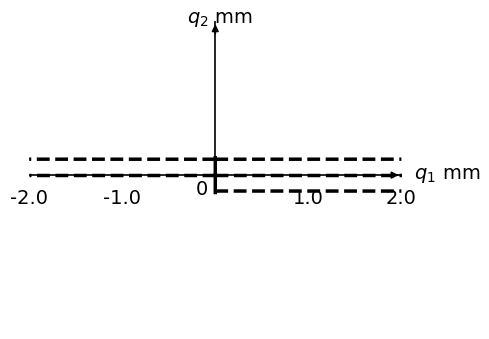

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---- settings ----
xlim = (-2, 2)   # q1
ylim = (-2, 2)   # q2
line_thickness = 2.5

# ---- load & plot ----
fig, ax = plt.subplots(figsize=(5, 3.5))
axis_at_origin(ax, xlim, ylim, r'$q_1$ mm', r'$q_2$ mm')

for i in [0, 1, 2, 3, 4, 5, 6, 7]:
    file_path = f'Solution{i}_0.csv'
    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path, skiprows=[1])
    q1 = df['Data_7'] * 50  # q1
    q2 = df['Data_6'] * 50  # q2

    mask = q1.between(*xlim) & q2.between(*ylim)
    q1, q2 = q1[mask].to_numpy(), q2[mask].to_numpy()

    if i == 0:
        ax.plot(q1, q2, linestyle='-', lw=line_thickness,
                color='black', label='Solution 0')
    else:
        dash = '-' if i in [1, 2] else '--'
        ax.plot(q1, q2, linestyle=dash, lw=line_thickness,
                color='black', label=f'Solution {i}')

fig.tight_layout()
plt.show()


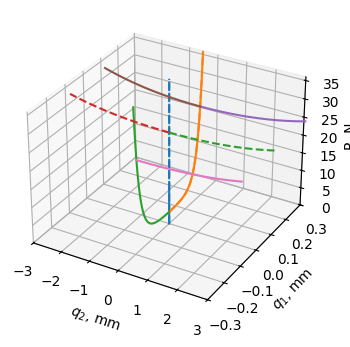

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

fig = plt.figure(figsize=(4, 6))#, constrained_layout=True
ax = fig.add_subplot(111, projection='3d')
lim = 3.5

for i in [0, 1, 2, 3, 4, 5, 6, 7]:
    file_path = f'Solutiona=4.25/Solution{i}_0.csv'
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, skiprows=[1])
        q1 = df['Data_7'] * 50/2
        q2 = df['Data_6'] * 50
        PAR = df['Data_4']  # y-axis in your terms

        # Filter data within range
        mask = (q1 >= -lim) & (q1 <= lim) & (q2 >= -lim) & (q2 <= lim)
        q1_filtered = q1[mask]
        q2_filtered = q2[mask]
        PAR_filtered = PAR[mask]

        if i == 0:
            # Solid for PAR ≤ 86
            mask_solid = PAR_filtered <= 10
            ax.plot(q1_filtered[mask_solid],
                    q2_filtered[mask_solid],
                    PAR_filtered[mask_solid],
                    linestyle='-', color='C0', label='Solution 0 (≤ 86)')

            # Dashed for PAR > 86
            mask_dash = PAR_filtered > 10
            ax.plot(q1_filtered[mask_dash],
                    q2_filtered[mask_dash],
                    PAR_filtered[mask_dash],
                    linestyle='--', color='C0', label='Solution 0 (> 86)')
        if i == 1:
            # Solid for PAR ≤ 86
            mask_solid = PAR_filtered <= 50
            ax.plot(q1_filtered[mask_solid],
                    q2_filtered[mask_solid],
                    PAR_filtered[mask_solid],
                    linestyle='-', color='C1', label='Solution 0 (≤ 86)')

            # Dashed for PAR > 86
            mask_dash = PAR_filtered > 50
            ax.plot(q1_filtered[mask_dash],
                    q2_filtered[mask_dash],
                    PAR_filtered[mask_dash],
                    linestyle='--', color='C1', label='Solution 0 (> 86)')
        if i == 2:
            # Solid for PAR ≤ 86
            mask_solid = PAR_filtered <= 50
            ax.plot(q1_filtered[mask_solid],
                    q2_filtered[mask_solid],
                    PAR_filtered[mask_solid],
                    linestyle='-', color='C2', label='Solution 0 (≤ 86)')

            # Dashed for PAR > 86
            mask_dash = PAR_filtered > 50
            ax.plot(q1_filtered[mask_dash],
                    q2_filtered[mask_dash],
                    PAR_filtered[mask_dash],
                    linestyle='--', color='C2', label='Solution 0 (> 86)')

        else:
            # For other solutions: 0,1,2 solid; 3,4 dashed
            linestyle = '-' if i in [5,6,7] else '--'
            ax.plot(q1_filtered, q2_filtered, PAR_filtered,
                    linestyle=linestyle, label=f'Solution {i}')

# Labels
ax.set_xlabel(r'$q_2$, mm')
ax.set_ylabel(r'$q_1$, mm')
ax.set_zlabel("P, N", rotation=90, labelpad=0.5) #, labelpad=10
#ax.set_title('3D Plot: PAR vs q₁ and q₂ (Solutions 0 to 4)')

# Axis limits
ax.set_xlim(-3, 3)
ax.set_ylim(-0.3, 0.3)
ax.set_zlim(0, 36)


plt.savefig("plot.png", bbox_inches="tight")
plt.show()

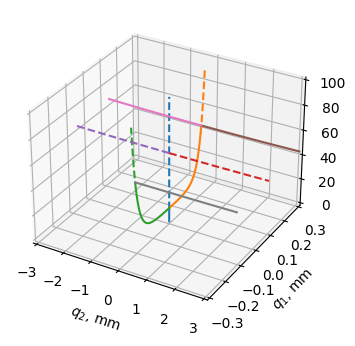

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

fig = plt.figure(figsize=(4, 6))
ax = fig.add_subplot(111, projection='3d')
lim = 3.5

# define a list of colors from matplotlib default cycle (C0–C7)
colors = [f"C{i}" for i in range(8)]

for i in range(8):
    file_path = f'Solution{i}_0.csv'
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, skiprows=[1])
        q1 = df['Data_7'] * 50
        q2 = df['Data_6'] * 50
        PAR = df['Data_4']

        # Filter data within range
        mask = (q1 >= -lim) & (q1 <= lim) & (q2 >= -lim) & (q2 <= lim)
        q1_filtered = q1[mask]
        q2_filtered = q2[mask]
        PAR_filtered = PAR[mask]

        # thresholds vary depending on solution index
        if i == 0:
            threshold = 10
        elif i in [1, 2]:
            threshold = 50
        else:
            threshold = None  # no split

        if threshold is not None:
            mask_solid = PAR_filtered <= threshold
            ax.plot(q1_filtered[mask_solid],
                    q2_filtered[mask_solid],
                    PAR_filtered[mask_solid],
                    linestyle='-', color=colors[i],
                    label=f"Solution {i} (≤ {threshold})")

            mask_dash = PAR_filtered > threshold
            ax.plot(q1_filtered[mask_dash],
                    q2_filtered[mask_dash],
                    PAR_filtered[mask_dash],
                    linestyle='--', color=colors[i],
                    label=f"Solution {i} (> {threshold})")
        else:
            # solid for 5,6,7; dashed for 3,4
            linestyle = '-' if i in [5, 6, 7] else '--'
            ax.plot(q1_filtered, q2_filtered, PAR_filtered,
                    linestyle=linestyle, color=colors[i],
                    label=f"Solution {i}")

# Labels
ax.set_xlabel(r'$q_2$, mm')
ax.set_ylabel(r'$q_1$, mm')
ax.set_zlabel("P, N", labelpad=10)

# Axis limits
ax.set_xlim(-3, 3)
ax.set_ylim(-0.3, 0.3)
ax.set_zlim(0, 100)

#ax.legend()
plt.savefig("plot.png", bbox_inches="tight")
plt.show()


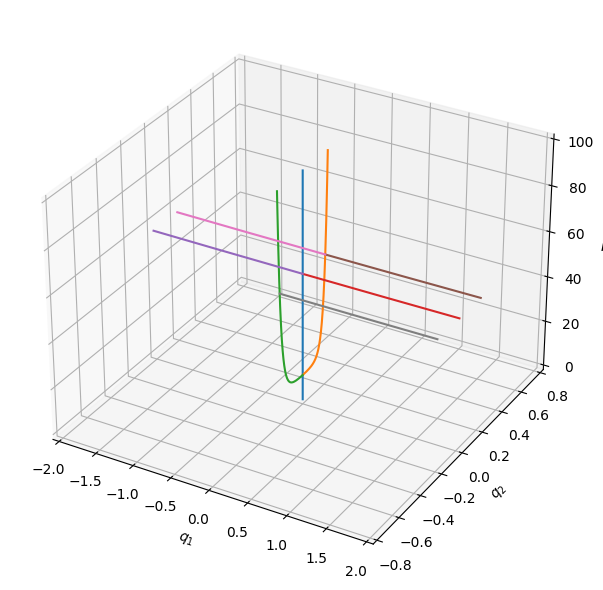

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# Settings
scale = 50
xlim = (-2, 2)       # q1 range
ylim = (-0.8, 0.8)   # q2 range
zlim = (0, 100)      # P range
solutions = [0, 1, 2, 3, 4, 5, 6, 7]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

for i in solutions:
    file_path = f'Solution{i}_0.csv'
    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path, skiprows=[1])
    q1 = df['Data_7'] * scale
    q2 = df['Data_6'] * scale
    P  = df['Data_4']

    mask = q1.between(*xlim) & q2.between(*ylim) & P.between(*zlim)
    q1, q2, P = q1[mask], q2[mask], P[mask]

    ax.plot(q1, q2, P, label=f'Solution {i}')

# Labels and limits
ax.set_xlabel(r'$q_1$')
ax.set_ylabel(r'$q_2$')
ax.set_zlabel(r'$P$')
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_zlim(*zlim)

# Optional legend
#ax.legend()

plt.tight_layout()
plt.show()

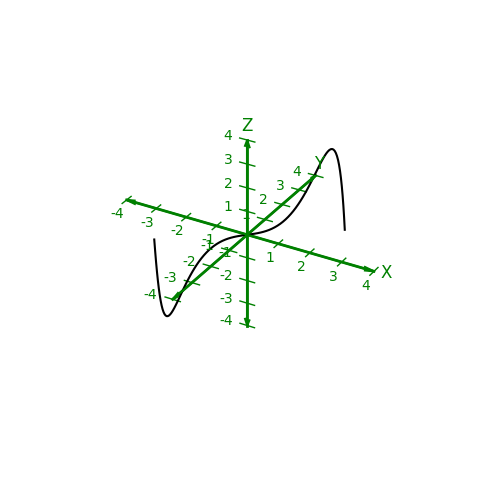

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def draw_textbook_axes(ax, limit=1, tick_step=1, color='green', lw=2):
    """
    Draw origin-centered X/Y/Z axes with arrowheads, ticks, and labels.
    Works on Matplotlib 3D without Arrow3D.
    """
    lim = float(limit)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)

    # Clean default box
    ax.grid(False)
    ax.xaxis.pane.set_visible(False); ax.yaxis.pane.set_visible(False); ax.zaxis.pane.set_visible(False)
    for spine in ax.spines.values(): spine.set_visible(False)

    # Axis lines
    ax.plot([-lim, lim], [0, 0], [0, 0], color=color, lw=lw)  # X
    ax.plot([0, 0], [-lim, lim], [0, 0], color=color, lw=lw)  # Y
    ax.plot([0, 0], [0, 0], [-lim, lim], color=color, lw=lw)  # Z

    # Arrowheads (quiver)
    ar = 0.08  # arrow length ratio
    ax.quiver(0,0,0,  lim,0,0,   arrow_length_ratio=ar, color=color)   # +X
    ax.quiver(0,0,0, -lim,0,0,   arrow_length_ratio=ar, color=color)   # -X
    ax.quiver(0,0,0,  0,lim,0,   arrow_length_ratio=ar, color=color)   # +Y
    ax.quiver(0,0,0,  0,-lim,0,  arrow_length_ratio=ar, color=color)   # -Y
    ax.quiver(0,0,0,  0,0,lim,   arrow_length_ratio=ar, color=color)   # +Z
    ax.quiver(0,0,0,  0,0,-lim,  arrow_length_ratio=ar, color=color)   # -Z

    # Ticks (little cross marks) + numeric labels
    tick_len = 0.06*lim
    ticks = np.arange(-lim, lim+1e-9, tick_step)
    # X ticks
    for t in ticks:
        if abs(t) < 1e-12: continue
        ax.plot([t, t], [-tick_len, tick_len], [0, 0], color=color, lw=1)
        ax.text(t, -2*tick_len, 0, f"{int(t) if t.is_integer() else t}", ha='center', va='top', color=color)
    # Y ticks
    for t in ticks:
        if abs(t) < 1e-12: continue
        ax.plot([-tick_len, tick_len], [t, t], [0, 0], color=color, lw=1)
        ax.text(-2*tick_len, t, 0, f"{int(t) if t.is_integer() else t}", ha='right', va='center', color=color)
    # Z ticks
    for t in ticks:
        if abs(t) < 1e-12: continue
        ax.plot([-tick_len, tick_len], [0, 0], [t, t], color=color, lw=1)
        ax.text(-2*tick_len, 0, t, f"{int(t) if t.is_integer() else t}", ha='right', va='center', color=color)

    # Axis labels near arrow tips
    ax.text(lim*1.05, 0, 0, 'X', color=color, ha='left', va='center', fontsize=12)
    ax.text(0, lim*1.05, 0, 'Y', color=color, ha='center', va='bottom', fontsize=12)
    ax.text(0, 0, lim*1.05, 'Z', color=color, ha='center', va='bottom', fontsize=12)

    # Hide default ticks
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

# ---------------- Example usage with your data ----------------
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
draw_textbook_axes(ax, limit=4, tick_step=1, color='green', lw=2)

# Example q1, q2, P data
q1 = np.linspace(-3, 3, 100)
q2 = np.sin(q1)
P  = q1**2*q2

ax.plot(q1, q2, P, color='black')

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_zlim(-4, 4)
ax.axis('off')  # hide default box

plt.show()

/tmp/ipykernel_168/312366650.py:25: MatplotlibDeprecationWarning: The w_xaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use xaxis instead.
  ax.w_xaxis.line.set_color((1,1,1,0))
/tmp/ipykernel_168/312366650.py:26: MatplotlibDeprecationWarning: The w_yaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use yaxis instead.
  ax.w_yaxis.line.set_color((1,1,1,0))
/tmp/ipykernel_168/312366650.py:27: MatplotlibDeprecationWarning: The w_zaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use zaxis instead.
  ax.w_zaxis.line.set_color((1,1,1,0))


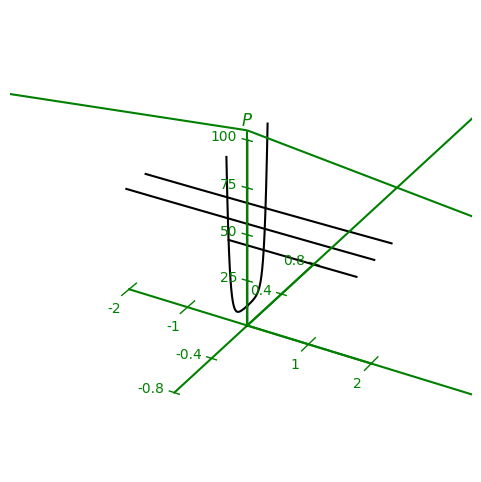

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def draw_textbook_axes(ax, x_range=(-2, 2), y_range=(-0.8, 0.8), z_range=(0, 100),
                       tick_step=None,
                       labels=(r'$q_1$', r'$q_2$', r'$P$'),
                       color='green', lw=2,
                       arrow_ratio=0.12):
    """
    Draws 3D coordinate axes with ticks, only positive-direction arrows, and adjustable ranges.
    """
    ax.set_xlim(*x_range)
    ax.set_ylim(*y_range)
    ax.set_zlim(*z_range)

    # Hide grid, panes, ticks, and all box lines
    ax.grid(False)
    for p in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        p.set_visible(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.w_xaxis.line.set_color((1,1,1,0))
    ax.w_yaxis.line.set_color((1,1,1,0))
    ax.w_zaxis.line.set_color((1,1,1,0))
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

    # Disable scientific notation
    ax.zaxis.get_major_formatter().set_scientific(False)

    # Auto tick step if not given
    if tick_step is None:
        def auto_step(rng):
            span = rng[1] - rng[0]
            step = span / 4
            return round(step, 2)
        tick_step = (
            auto_step(x_range),
            auto_step(y_range),
            auto_step(z_range)
        )

    arrow_offset = 0.05 * max(x_range[1], y_range[1], z_range[1])

    # X axis
    ax.plot([x_range[0], x_range[1]], [0, 0], [0, 0], color=color, lw=lw)
    ax.quiver(0,0,0,  x_range[1]+arrow_offset,0,0, arrow_length_ratio=arrow_ratio, color=color)

    # Y axis
    ax.plot([0, 0], [y_range[0], y_range[1]], [0, 0], color=color, lw=lw)
    ax.quiver(0,0,0, 0,y_range[1]+arrow_offset,0, arrow_length_ratio=arrow_ratio, color=color)

    # Z axis
    ax.plot([0, 0], [0, 0], [z_range[0], z_range[1]], color=color, lw=lw)
    ax.quiver(0,0,0, 0,0,z_range[1]+arrow_offset, arrow_length_ratio=arrow_ratio, color=color)

    # Tick marks & numbers
    tick_len = 0.02 * max((x_range[1]-x_range[0]), (y_range[1]-y_range[0]))
    for t in np.arange(x_range[0], x_range[1]+1e-9, tick_step[0]):
        if abs(t) > 1e-12:
            ax.plot([t, t], [-tick_len, tick_len], [0, 0], color=color, lw=1)
            ax.text(t, -2*tick_len, 0, f"{t:.2g}", ha='center', va='top', color=color)
    for t in np.arange(y_range[0], y_range[1]+1e-9, tick_step[1]):
        if abs(t) > 1e-12:
            ax.plot([-tick_len, tick_len], [t, t], [0, 0], color=color, lw=1)
            ax.text(-2*tick_len, t, 0, f"{t:.2g}", ha='right', va='center', color=color)
    for t in np.arange(z_range[0], z_range[1]+1e-9, tick_step[2]):
        if abs(t) > 1e-12:
            ax.plot([-tick_len, tick_len], [0, 0], [t, t], color=color, lw=1)
            ax.text(-2*tick_len, 0, t, f"{t:.0f}", ha='right', va='center', color=color)  # integer style

    # Axis labels
    ax.text(x_range[1]+arrow_offset, 0, 0, labels[0], color=color, ha='left', va='center', fontsize=12)
    ax.text(0, y_range[1]+arrow_offset, 0, labels[1], color=color, ha='center', va='bottom', fontsize=12)
    ax.text(0, 0, z_range[1]+arrow_offset, labels[2], color=color, ha='center', va='bottom', fontsize=12)


# ======== Your data plotting with custom axes ========
scale = 50
xlim = (-2, 2)
ylim = (-0.8, 0.8)
zlim = (0, 100)
solutions = [0, 1, 2, 3, 4, 5, 6, 7]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
draw_textbook_axes(ax, x_range=xlim, y_range=ylim, z_range=zlim,
                   labels=(r'$q_1$', r'$q_2$', r'$P$'),
                   color='green', lw=1.5, arrow_ratio=0.15)

for i in solutions:
    file_path = f'Solution{i}_0.csv'
    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path, skiprows=[1])
    q1 = df['Data_7'] * scale
    q2 = df['Data_6'] * scale
    P  = df['Data_4']

    mask = q1.between(*xlim) & q2.between(*ylim) & P.between(*zlim)
    q1, q2, P = q1[mask], q2[mask], P[mask]

    ax.plot(q1, q2, P, label=f'Solution {i}', color='black', lw=1.5)

plt.show()


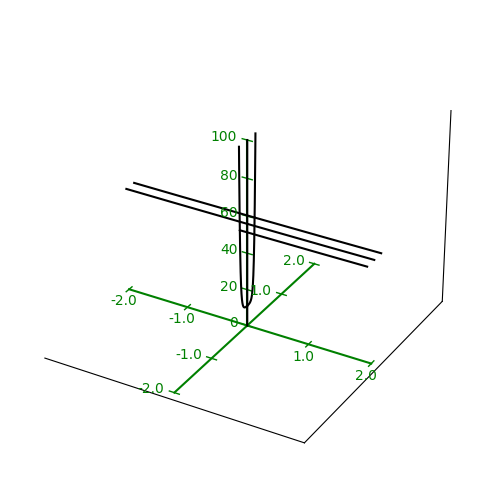

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

def draw_textbook_axes(ax, x_range=(-2,2), y_range=(-2,2), z_range=(0,100),
                       labels=(r'$q_1$', r'$q_2$', r'$P$'),
                       tick_step=None, color='green', lw=1.5):
    """Draw 3D axes at origin without arrows."""
    ax.set_xlim(*x_range)
    ax.set_ylim(*y_range)
    ax.set_zlim(*z_range)
    ax.grid(False)

    # Remove panes and default ticks
    for p in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        p.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

    # Axis lines
    ax.plot([x_range[0], x_range[1]], [0, 0], [0, 0], color=color, lw=lw)  # X
    ax.plot([0, 0], [y_range[0], y_range[1]], [0, 0], color=color, lw=lw)  # Y
    ax.plot([0, 0], [0, 0], [z_range[0], z_range[1]], color=color, lw=lw)  # Z

    # Tick placement
    if tick_step is None:
        tick_x = np.linspace(x_range[0], x_range[1], 5)
        tick_y = np.linspace(y_range[0], y_range[1], 5)
        tick_z = np.linspace(z_range[0], z_range[1], 6)
    else:
        tick_x = np.arange(x_range[0], x_range[1]+1e-9, tick_step)
        tick_y = np.arange(y_range[0], y_range[1]+1e-9, tick_step)
        tick_z = np.arange(z_range[0], z_range[1]+1e-9, tick_step)

    tick_len = 0.02 * max((x_range[1]-x_range[0]), (y_range[1]-y_range[0]))
    
    # X ticks
    for tx in tick_x:
        if abs(tx) > 1e-12:
            ax.plot([tx, tx], [-tick_len, tick_len], [0, 0], color=color, lw=1)
            ax.text(tx, -2*tick_len, 0, f"{tx:.1f}", ha='center', va='top', color=color)
    # Y ticks
    for ty in tick_y:
        if abs(ty) > 1e-12:
            ax.plot([-tick_len, tick_len], [ty, ty], [0, 0], color=color, lw=1)
            ax.text(-2*tick_len, ty, 0, f"{ty:.1f}", ha='right', va='center', color=color)
    # Z ticks
    for tz in tick_z:
        ax.plot([-tick_len, tick_len], [0, 0], [tz, tz], color=color, lw=1)
        ax.text(-2*tick_len, 0, tz, f"{int(tz)}", ha='right', va='center', color=color)

    # Labels
    ax.text(x_range[1], 0, 0, labels[0], ha='left', va='center', fontsize=14, color=color)
    ax.text(0, y_range[1], 0, labels[1], ha='center', va='bottom', fontsize=14, color=color)
    ax.text(0, 0, z_range[1], labels[2], ha='center', va='bottom', fontsize=14, color=color)

# ======== Your data plotting ========
scale = 50
xlim = (-2, 2)
ylim = (-2, 2)
zlim = (0, 100)
solutions = [0, 1, 2, 3, 4, 5, 6, 7]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
draw_textbook_axes(ax, x_range=xlim, y_range=ylim, z_range=zlim,
                   labels=(r'', r'', r''),
                   color='green', lw=1.5)

for i in solutions:
    file_path = f'Solution{i}_0.csv'
    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path, skiprows=[1])
    q1 = df['Data_7'] * scale
    q2 = df['Data_6'] * scale
    P  = df['Data_4']

    mask = q1.between(*xlim) & q2.between(*ylim) & P.between(*zlim)
    q1, q2, P = q1[mask], q2[mask], P[mask]

    ax.plot(q1, q2, P, color='black', lw=1.5)

plt.show()

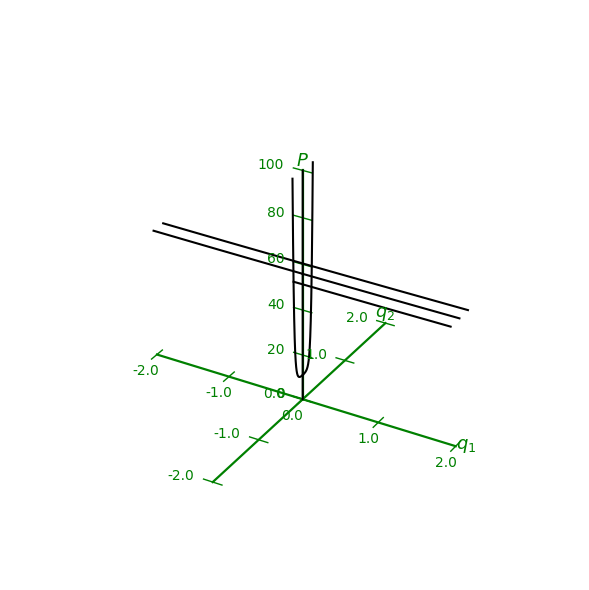

In [65]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def draw_textbook_axes(ax, x_range=(-2, 2), y_range=(-0.8, 0.8), z_range=(0, 100),
                       labels=(r'$q_1$', r'$q_2$', r'$P$'),
                       color='green', lw=1.6, tick_nx=5, tick_ny=5, tick_nz=6):
    """Origin-centered 3D axes (no box), ticks, and labels—no arrows."""
    # Limits
    ax.set_xlim(*x_range)
    ax.set_ylim(*y_range)
    ax.set_zlim(*z_range)

    # Remove the 3D box/side lines and panes
    ax.grid(False)
    for p in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        p.set_visible(False)
    # Hide axis edge lines (new and old Matplotlib)
    try:
        ax.xaxis.line.set_color((1,1,1,0))
        ax.yaxis.line.set_color((1,1,1,0))
        ax.zaxis.line.set_color((1,1,1,0))
    except Exception:
        ax.w_xaxis.line.set_color((1,1,1,0))
        ax.w_yaxis.line.set_color((1,1,1,0))
        ax.w_zaxis.line.set_color((1,1,1,0))
    # No default ticks
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

    # Custom axis lines through origin
    ax.plot([x_range[0], x_range[1]], [0, 0], [0, 0], color=color, lw=lw)  # q1
    ax.plot([0, 0], [y_range[0], y_range[1]], [0, 0], color=color, lw=lw)  # q2
    ax.plot([0, 0], [0, 0], [z_range[0], z_range[1]], color=color, lw=lw)  # P

    # Ticks
    tx = np.linspace(*x_range, tick_nx)
    ty = np.linspace(*y_range, tick_ny)
    tz = np.linspace(*z_range, tick_nz)  # e.g., 0..100 -> 0,20,40,60,80,100

    tick_len = 0.03 * max((x_range[1]-x_range[0]), (y_range[1]-y_range[0]))

    # q1 ticks and labels
    for t in tx:
        ax.plot([t, t], [-tick_len, tick_len], [0, 0], color=color, lw=1)
        ax.text(t, -2*tick_len, 0, f"{t:.1f}", ha='center', va='top', color=color)
    # q2 ticks and labels
    for t in ty:
        ax.plot([-tick_len, tick_len], [t, t], [0, 0], color=color, lw=1)
        ax.text(-2*tick_len, t, 0, f"{t:.1f}", ha='right', va='center', color=color)
    # P ticks and labels
    for t in tz:
        ax.plot([-tick_len, tick_len], [0, 0], [t, t], color=color, lw=1)
        ax.text(-2*tick_len, 0, t, f"{int(t)}", ha='right', va='center', color=color)

    # Axis labels at the ends
    ax.text(x_range[1], 0, 0, labels[0], ha='left',  va='center', fontsize=13, color=color)
    ax.text(0, y_range[1], 0, labels[1], ha='center', va='bottom', fontsize=13, color=color)
    ax.text(0, 0, z_range[1], labels[2], ha='center', va='bottom', fontsize=13, color=color)


# ======== Your data plotting with hidden box ========
scale = 50
xlim = (-2, 2)      # q1
ylim = (-2, 2)  # q2
zlim = (0, 100)     # P
solutions = [0, 1, 2, 3, 4, 5, 6, 7]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

# Set tick_nz=6 so P shows 0,20,40,60,80,100 automatically
draw_textbook_axes(ax, x_range=xlim, y_range=ylim, z_range=zlim,
                   labels=(r'$q_1$', r'$q_2$', r'$P$'),
                   color='green', lw=1.6, tick_nx=5, tick_ny=5, tick_nz=6)

for i in solutions:
    file_path = f"Solution{i}_0.csv"
    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path, skiprows=[1])
    q1 = df['Data_7'] * scale
    q2 = df['Data_6'] * scale
    P  = df['Data_4']

    mask = q1.between(*xlim) & q2.between(*ylim) & P.between(*zlim)
    ax.plot(q1[mask], q2[mask], P[mask], color='black', lw=1.5)

plt.tight_layout()
plt.show()

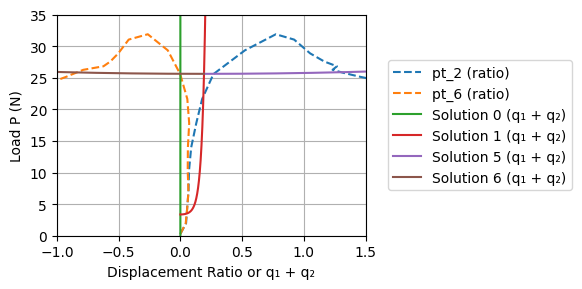

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the processed Excel file
xlsx_path = 'UC_0.8_perfect_shifted_1.xlsx'
df_ratio = pd.read_excel(xlsx_path)

# Try loading Solution5 and Solution6 for q1 + q2 vs PAR
solution_data = []

for i in [0,1,5,6]:
    try:
        csv_path = f'Solution{i}_0.csv'
        df = pd.read_csv(csv_path, skiprows=[1])
        q1 = df['Data_7']*50/2
        q2 = df['Data_6']*50
        q_total = q1 + q2
        PAR = df['Data_4']
        solution_data.append((q_total, PAR, f'Solution {i}'))
    except:
        continue

# Prepare plot
plt.figure(figsize=(6, 3))

# Plot pt_2 and pt_7
for i in [2, 6]:
    subset = df_ratio[df_ratio["Point"] == f"pt_{i}"]
    plt.plot(subset["ratio_shifted"], subset["P"], label=f'pt_{i} (ratio)', linestyle='--')

# Plot q1+q2 vs PAR
for q_total, PAR, label in solution_data:
    plt.plot(q_total, PAR, label=f'{label} (q₁ + q₂)', linestyle='-')

# Labels and layout
plt.xlabel("Displacement Ratio or q₁ + q₂")
plt.ylabel("Load P (N)")
plt.ylim(0, 35)
plt.xlim(-1, 1.5)
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.tight_layout()
plt.show()


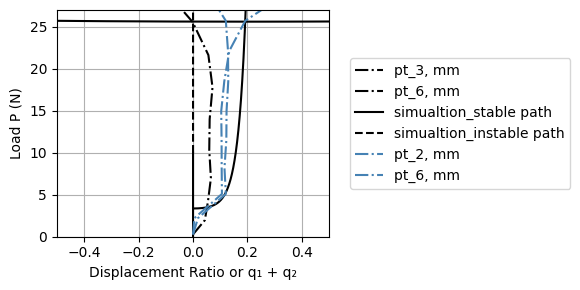

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the processed Excel file
xlsx_path = 'UC_0.8_perfect_shifted_1.xlsx'  #10,13 UC_20250313_UC_Ri_13
#mean_P_vs_ratio_with_time_13_10_1
df_ratio = pd.read_excel(xlsx_path)

# Try loading Solution0,1,5,6 for q1+q2 vs PAR
solution_data = []

for i in [0, 1, 5, 6]:
    try:
        csv_path = f'Solutiona=4/Solution{i}_0.csv'
        df = pd.read_csv(csv_path, skiprows=[1])
        q1 = df['Data_7'] * 50 / 2
        q2 = df['Data_6'] * 50
        q_total = q1 + q2
        PAR = df['Data_4']
        solution_data.append((q_total, PAR, i))
    except FileNotFoundError:
        continue

# Prepare plot
#plt.figure(figsize=(7, 3))
plt.figure(figsize=(6, 3))
# Plot pt_2 and pt_7 from Excel data
for i in [3, 6]:
    subset = df_ratio[df_ratio["Point"] == f"pt_{i}"]
    plt.plot(subset["ratio_shifted"], subset["P"],
             label=f'pt_{i}, mm', linestyle='-.',color='black')

# Plot q1+q2 vs PAR with masks for Solution 0 & 1
# Plot q1+q2 vs PAR with masks for Solution 0 & 1
for q_total, PAR, idx in solution_data:
    color = "k"   # force all black
    
    if idx == 0:
        thr = 10
        mask_solid = PAR <= thr
        mask_dash  = PAR > thr
        plt.plot(q_total[mask_solid], PAR[mask_solid],
                 linestyle='-', color=color, label="simualtion_stable path")
        plt.plot(q_total[mask_dash], PAR[mask_dash],
                 linestyle='--', color=color, label="simualtion_instable path")
        
    elif idx == 1:
        thr = 86
        mask_solid = PAR <= thr
        mask_dash  = PAR > thr
        plt.plot(q_total[mask_solid], PAR[mask_solid],
                 linestyle='-', color=color) #, label="Solution 1 (≤ 86)"
        plt.plot(q_total[mask_dash], PAR[mask_dash],
                 linestyle='--', color=color) #, label="Solution 1 (> 86)"
        
    else:  # Solutions 5 and 6 (normal)
        plt.plot(q_total, PAR, linestyle='-', color=color) #, label=f"Solution {idx}"




# Load the processed Excel file
xlsx_path = '20260203_UC0.8_1.4_DIC_shifted6.xlsx'  #10,13 UC_20250313_UC_Ri_13
#mean_P_vs_ratio_with_time_13_10_1
df_ratio_1 = pd.read_excel(xlsx_path)

# Try loading Solution0,1,5,6 for q1+q2 vs PAR
solution_data = []

for i in [0, 1, 5, 6]:
    try:
        csv_path = f'Solution{i}_0.csv'
        df = pd.read_csv(csv_path, skiprows=[1])
        q1 = df['Data_7'] * 50 / 2
        q2 = df['Data_6'] * 50
        q_total = q1 + q2
        PAR = df['Data_4']
        solution_data.append((q_total, PAR, i))
    except FileNotFoundError:
        continue

# Plot pt_2 and pt_7 from Excel data
for i in [2, 6]:
    subset = df_ratio_1[df_ratio_1["Point"] == f"pt_{i}"]
    plt.plot(subset["ratio_shifted"], subset["P"],
             label=f'pt_{i}, mm', linestyle='-.',color='steelblue')


# Plot q1+q2 vs PAR with masks for Solution 0 & 1
# Plot q1+q2 vs PAR with masks for Solution 0 & 1
for q_total, PAR, idx in solution_data:
    color = "k"   # force all black
    
    if idx == 0:
        thr = 3
        mask_solid = PAR <= thr
        mask_dash  = PAR > thr
        plt.plot(q_total[mask_solid], PAR[mask_solid],
                 linestyle='-', color='steelblue', label="simualtion_stable path")
        plt.plot(q_total[mask_dash], PAR[mask_dash],
                 linestyle='--', color='steelblue', label="simualtion_instable path")
        
    elif idx == 1:
        thr = 25
        mask_solid = PAR <= thr
        mask_dash  = PAR > thr
        plt.plot(q_total[mask_solid], PAR[mask_solid],
                 linestyle='-', color='steelblue') #, label="Solution 1 (≤ 86)"
        plt.plot(q_total[mask_dash], PAR[mask_dash],
                 linestyle='--', color='steelblue') #, label="Solution 1 (> 86)"
        
    else:  # Solutions 5 and 6 (normal)
        plt.plot(q_total, PAR, linestyle='-', color='steelblue') #, label=f"Solution {idx}"


# Labels and layout
plt.xlabel("Displacement Ratio or q₁ + q₂")
plt.ylabel("Load P (N)")
plt.ylim(0, 27)
plt.xlim(-0.5, 0.5)
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.tight_layout()
plt.show()